In [ ]:
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
# Load a medium-sized text dataset (AG News Classification)
dataset, dataset_info = tfds.load("ag_news_subset", as_supervised=True, with_info=True)
data_train, data_test = dataset["train"].batch(128), dataset["test"].batch(128)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.JYJLRR_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.JYJLRR_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.


In [ ]:
# Load text vectorization
text_vectorizer = keras.layers.TextVectorization(max_tokens=20000, output_mode="int", output_sequence_length=256)

In [ ]:
# Prepare text vectorization
text_only_train = data_train.map(lambda x, y: x)
text_vectorizer.adapt(text_only_train)

In [ ]:
# Build the model
inputs = keras.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = keras.layers.Embedding(input_dim=20000, output_dim=32)(x)
x = keras.layers.Conv1D(64, kernel_size=5, activation="relu")(x)
x = keras.layers.GlobalMaxPooling1D()(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dense(4, activation="softmax")(x)  # 4 classes for AG News
model = keras.Model(inputs, x)

In [ ]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Display sample text from dataset
sample_text, sample_label = next(iter(data_train.take(1)))
for i in range(3):  # Show 3 text samples
    print(f"News {i+1}: {sample_text[i].numpy().decode('utf-8')}")
    print(f"Category: {sample_label[i].numpy()}\n")

News 1: AMD #39;s new dual-core Opteron chip is designed mainly for corporate computing applications, including databases, Web services, and financial transactions.
Category: 3

News 2: Reuters - Major League Baseball\Monday announced a decision on the appeal filed by Chicago Cubs\pitcher Kerry Wood regarding a suspension stemming from an\incident earlier this season.
Category: 1

News 3: President Bush #39;s  quot;revenue-neutral quot; tax reform needs losers to balance its winners, and people claiming the federal deduction for state and local taxes may be in administration planners #39; sights, news reports say.
Category: 2



In [ ]:
# Train the model
history = model.fit(data_train, validation_data=data_test, epochs=5)  # More epochs than Easy level

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 70ms/step - accuracy: 0.7283 - loss: 0.6978 - val_accuracy: 0.9050 - val_loss: 0.2933
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9220 - loss: 0.2336 - val_accuracy: 0.9086 - val_loss: 0.2875
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9470 - loss: 0.1595 - val_accuracy: 0.9051 - val_loss: 0.3186
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9689 - loss: 0.0998 - val_accuracy: 0.8978 - val_loss: 0.3938
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9828 - loss: 0.0577 - val_accuracy: 0.8918 - val_loss: 0.4768


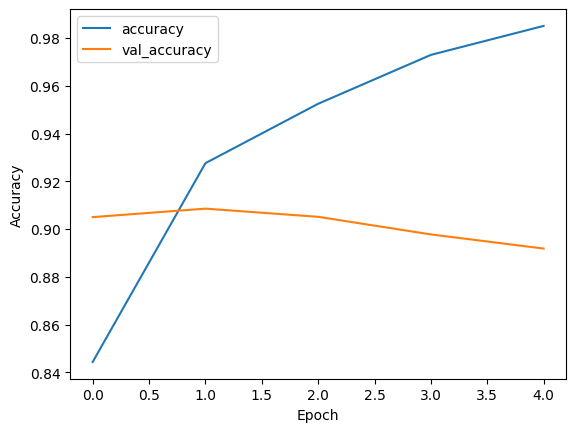

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Summary of Achievements
print("Summary of Achievements:")
print("- Implemented a text classification model for AG News.")
print("- Used TextVectorization for preprocessing.")
print("- Introduced a Conv1D layer for feature extraction.")
print("- Achieved efficient execution with 5 training epochs.")

Summary of Achievements:
- Implemented a text classification model for AG News.
- Used TextVectorization for preprocessing.
- Introduced a Conv1D layer for feature extraction.
- Achieved efficient execution with 5 training epochs.
